<a href="https://colab.research.google.com/github/adityaaaa342/Pattern-Recognition-/blob/main/Postlab_Pr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q seaborn scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from tensorflow.keras import layers, models

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    silhouette_score,
    pairwise_distances
)

print("TensorFlow version:", tf.__version__)
print("Libraries loaded successfully!")

TensorFlow version: 2.20.0
Libraries loaded successfully!


In [2]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()
y_train = y_train.flatten()
y_test = y_test.flatten()

print("Training data shape:", X_train.shape)
print("Training labels shape:", y_train.shape)

print("Testing data shape :", X_test.shape)
print("Testing labels shape:", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1851s 11us/step
Training data shape: (50000, 32, 32, 3)
Training labels shape: (50000,)
Testing data shape : (10000, 32, 32, 3)
Testing labels shape: (10000,)


In [3]:
class_names = [
    "Airplane",
    "Automobile",
    "Bird",
    "Cat",
    "Deer",
    "Dog",
    "Frog",
    "Horse",
    "Ship",
    "Truck"
]

print("CIFAR-10 Classes:")
for i, name in enumerate(class_names):
    print(i, "->", name)

CIFAR-10 Classes:
0 -> Airplane
1 -> Automobile
2 -> Bird
3 -> Cat
4 -> Deer
5 -> Dog
6 -> Frog
7 -> Horse
8 -> Ship
9 -> Truck


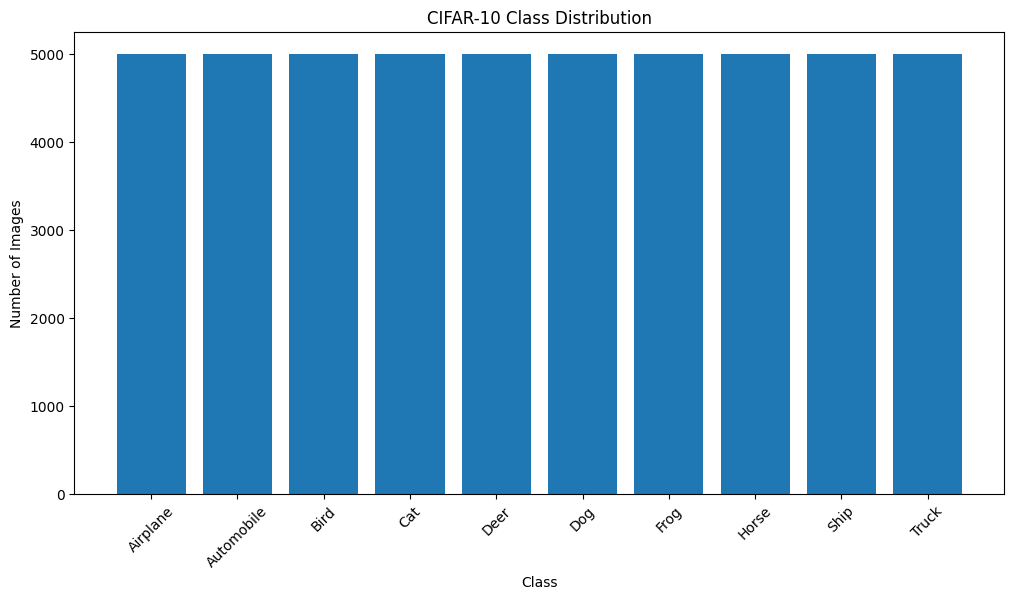

In [4]:
class_counts = np.bincount(
    y_train,
    minlength=10
)

plt.figure(figsize=(12, 6))

plt.bar(
    class_names,
    class_counts
)

plt.title("CIFAR-10 Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.xticks(rotation=45)

plt.show()

In [5]:
X_train_normalized = (
    X_train.astype("float32") / 255.0
)

X_test_normalized = (
    X_test.astype("float32") / 255.0
)

print("Before normalization:")
print("Minimum:", X_train.min())
print("Maximum:", X_train.max())

print("\nAfter normalization:")
print("Minimum:", X_train_normalized.min())
print("Maximum:", X_train_normalized.max())

Before normalization:
Minimum: 0
Maximum: 255

After normalization:
Minimum: 0.0
Maximum: 1.0


In [6]:
X_train_normalized = (
    X_train.astype("float32") / 255.0
)

X_test_normalized = (
    X_test.astype("float32") / 255.0
)

print("Before normalization:")
print("Minimum:", X_train.min())
print("Maximum:", X_train.max())

print("\nAfter normalization:")
print("Minimum:", X_train_normalized.min())
print("Maximum:", X_train_normalized.max())

Before normalization:
Minimum: 0
Maximum: 255

After normalization:
Minimum: 0.0
Maximum: 1.0


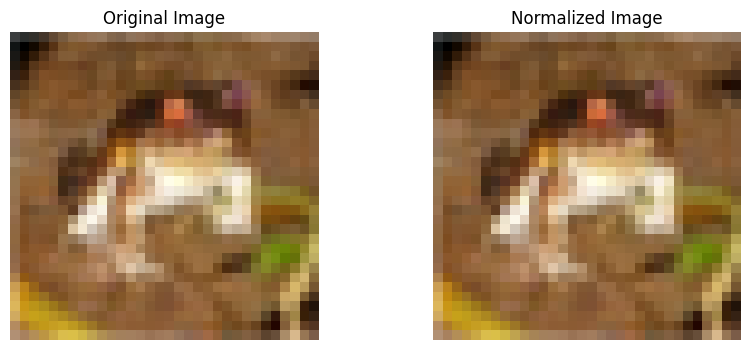

In [7]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)

plt.imshow(X_train[0])

plt.title("Original Image")
plt.axis("off")


plt.subplot(1, 2, 2)

plt.imshow(X_train_normalized[0])

plt.title("Normalized Image")
plt.axis("off")

plt.show()

In [8]:
def extract_features(images):

    feature_list = []

    for image in images:

        image = (
            image.astype("float32")
            / 255.0
        )

        # Mean RGB
        mean_rgb = np.mean(
            image,
            axis=(0, 1)
        )

        # Standard deviation RGB
        std_rgb = np.std(
            image,
            axis=(0, 1)
        )

        # Minimum RGB
        min_rgb = np.min(
            image,
            axis=(0, 1)
        )

        # Maximum RGB
        max_rgb = np.max(
            image,
            axis=(0, 1)
        )

        # Convert to grayscale
        gray = np.mean(
            image,
            axis=2
        )

        # Edge information
        edges_x = np.diff(
            gray,
            axis=1
        )

        edges_y = np.diff(
            gray,
            axis=0
        )

        edge_density = (
            np.mean(np.abs(edges_x))
            +
            np.mean(np.abs(edges_y))
        )

        features = np.concatenate([
            mean_rgb,
            std_rgb,
            min_rgb,
            max_rgb,
            [edge_density]
        ])

        feature_list.append(features)

    return np.array(feature_list)

In [9]:
def extract_features(images):

    feature_list = []

    for image in images:

        image = (
            image.astype("float32")
            / 255.0
        )

        # Mean RGB
        mean_rgb = np.mean(
            image,
            axis=(0, 1)
        )

        # Standard deviation RGB
        std_rgb = np.std(
            image,
            axis=(0, 1)
        )

        # Minimum RGB
        min_rgb = np.min(
            image,
            axis=(0, 1)
        )

        # Maximum RGB
        max_rgb = np.max(
            image,
            axis=(0, 1)
        )

        # Convert to grayscale
        gray = np.mean(
            image,
            axis=2
        )

        # Edge information
        edges_x = np.diff(
            gray,
            axis=1
        )

        edges_y = np.diff(
            gray,
            axis=0
        )

        edge_density = (
            np.mean(np.abs(edges_x))
            +
            np.mean(np.abs(edges_y))
        )

        features = np.concatenate([
            mean_rgb,
            std_rgb,
            min_rgb,
            max_rgb,
            [edge_density]
        ])

        feature_list.append(features)

    return np.array(feature_list)

In [10]:
CLASSICAL_SIZE = 5000

X_classical = X_train[:CLASSICAL_SIZE]
y_classical = y_train[:CLASSICAL_SIZE]

X_classical_test = X_test[:1000]
y_classical_test = y_test[:1000]

print("Classical training images:",
      X_classical.shape)

print("Classical testing images:",
      X_classical_test.shape)

Classical training images: (5000, 32, 32, 3)
Classical testing images: (1000, 32, 32, 3)


In [12]:
X_features = extract_features(
    X_classical
)

X_test_features = extract_features(
    X_classical_test
)

print(
    "Feature matrix shape:",
    X_features.shape
)

print(
    "Test feature matrix shape:",
    X_test_features.shape
)

Feature matrix shape: (5000, 13)
Test feature matrix shape: (1000, 13)


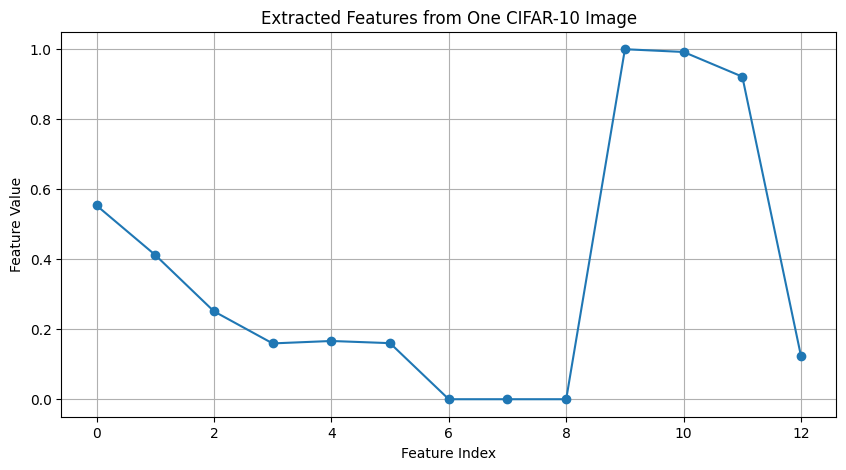

In [13]:
plt.figure(figsize=(10, 5))

plt.plot(
    X_features[0],
    marker="o"
)

plt.title(
    "Extracted Features from One CIFAR-10 Image"
)

plt.xlabel("Feature Index")
plt.ylabel("Feature Value")

plt.grid()

plt.show()

In [14]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X_features
)

X_test_scaled = scaler.transform(
    X_test_features
)

print(
    "Scaled feature shape:",
    X_scaled.shape
)

Scaled feature shape: (5000, 13)


In [15]:
k = min(
    8,
    X_scaled.shape[1]
)

selector = SelectKBest(
    score_func=f_classif,
    k=k
)

X_selected = selector.fit_transform(
    X_scaled,
    y_classical
)

X_test_selected = selector.transform(
    X_test_scaled
)

print(
    "Original features:",
    X_scaled.shape[1]
)

print(
    "Selected features:",
    X_selected.shape[1]
)

Original features: 13
Selected features: 8


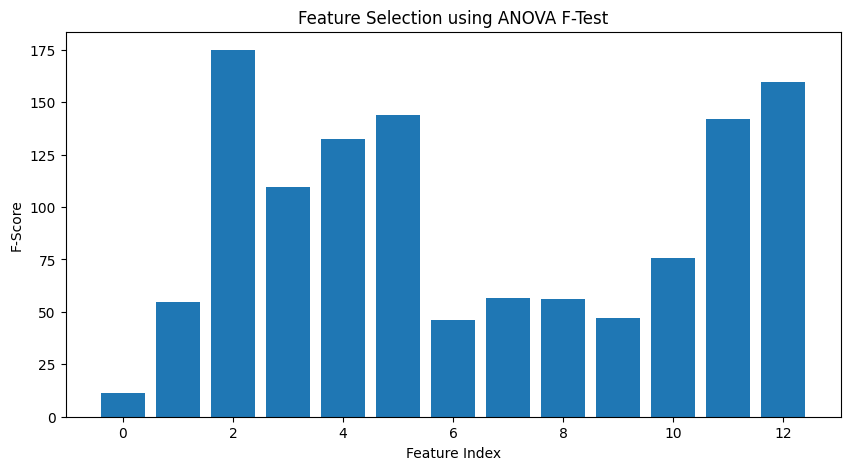

In [16]:
scores = selector.scores_

feature_indices = np.arange(
    len(scores)
)

plt.figure(figsize=(10, 5))

plt.bar(
    feature_indices,
    scores
)

plt.title(
    "Feature Selection using ANOVA F-Test"
)

plt.xlabel(
    "Feature Index"
)

plt.ylabel(
    "F-Score"
)

plt.show()

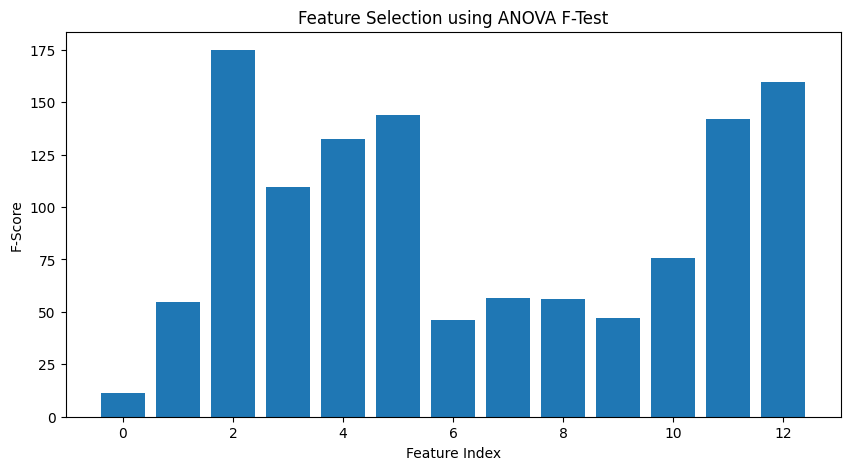

In [17]:
scores = selector.scores_

feature_indices = np.arange(
    len(scores)
)

plt.figure(figsize=(10, 5))

plt.bar(
    feature_indices,
    scores
)

plt.title(
    "Feature Selection using ANOVA F-Test"
)

plt.xlabel(
    "Feature Index"
)

plt.ylabel(
    "F-Score"
)

plt.show()

In [19]:
knn = KNeighborsClassifier(
    n_neighbors=5,
    metric="euclidean"
)

knn.fit(
    X_selected,
    y_classical
)

knn_prediction = knn.predict(
    X_test_selected
)

print(
    "KNN classification completed!"
)

KNN classification completed!


In [20]:
knn_accuracy = accuracy_score(
    y_classical_test,
    knn_prediction
)

knn_precision = precision_score(
    y_classical_test,
    knn_prediction,
    average="weighted",
    zero_division=0
)

knn_recall = recall_score(
    y_classical_test,
    knn_prediction,
    average="weighted",
    zero_division=0
)

knn_f1 = f1_score(
    y_classical_test,
    knn_prediction,
    average="weighted",
    zero_division=0
)

print("=" * 50)
print("             KNN RESULTS")
print("=" * 50)

print(
    "Accuracy :",
    round(knn_accuracy * 100, 2),
    "%"
)

print(
    "Precision:",
    round(knn_precision * 100, 2),
    "%"
)

print(
    "Recall   :",
    round(knn_recall * 100, 2),
    "%"
)

print(
    "F1 Score :",
    round(knn_f1 * 100, 2),
    "%"
)

             KNN RESULTS
Accuracy : 25.6 %
Precision: 26.87 %
Recall   : 25.6 %
F1 Score : 25.76 %


In [22]:
print(
    classification_report(
        y_classical_test,
        knn_prediction,
        target_names=class_names,
        zero_division=0
    )
)

              precision    recall  f1-score   support

    Airplane       0.23      0.34      0.28       103
  Automobile       0.18      0.27      0.22        89
        Bird       0.30      0.35      0.32       100
         Cat       0.13      0.13      0.13       103
        Deer       0.23      0.20      0.21        90
         Dog       0.15      0.14      0.15        86
        Frog       0.54      0.36      0.43       112
       Horse       0.19      0.14      0.16       102
        Ship       0.39      0.36      0.37       106
       Truck       0.28      0.25      0.26       109

    accuracy                           0.26      1000
   macro avg       0.26      0.25      0.25      1000
weighted avg       0.27      0.26      0.26      1000

              precision    recall  f1-score   support

    Airplane       0.23      0.34      0.28       103
  Automobile       0.18      0.27      0.22        89
        Bird       0.30      0.35      0.32       100
         Cat       0.13 

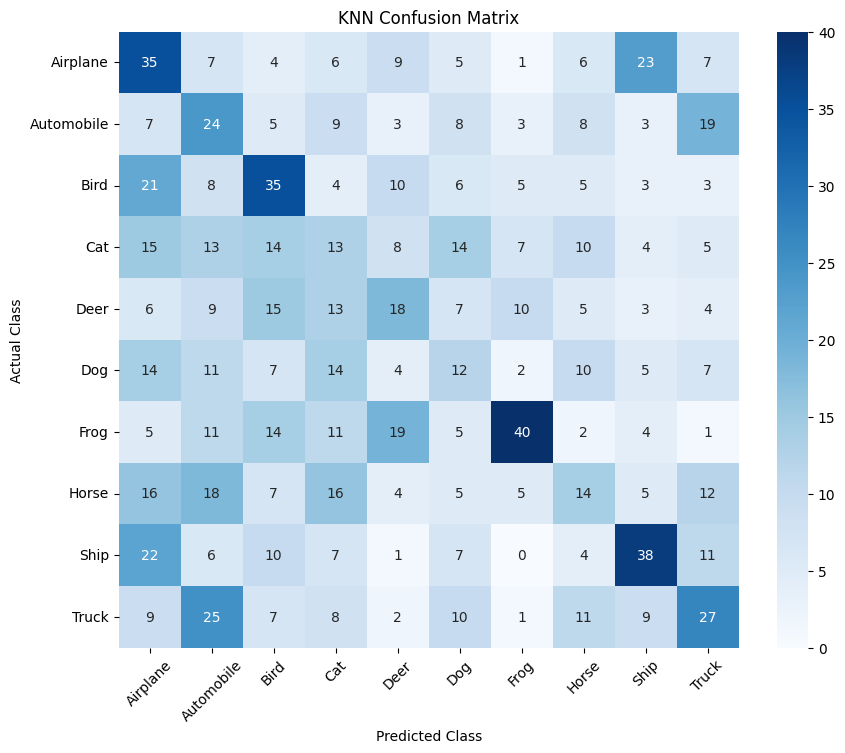

In [23]:
knn_cm = confusion_matrix(
    y_classical_test,
    knn_prediction
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    knn_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title(
    "KNN Confusion Matrix"
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "Actual Class"
)

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

In [24]:
kmeans = KMeans(
    n_clusters=10,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(
    X_selected
)

print(
    "K-Means clustering completed!"
)

print(
    "Number of clusters:",
    len(np.unique(clusters))
)

K-Means clustering completed!
Number of clusters: 10


In [25]:
pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(
    X_selected
)

print(
    "PCA completed!"
)

print(
    "Explained variance:",
    pca.explained_variance_ratio_
)

PCA completed!
Explained variance: [0.5422456  0.20247363]


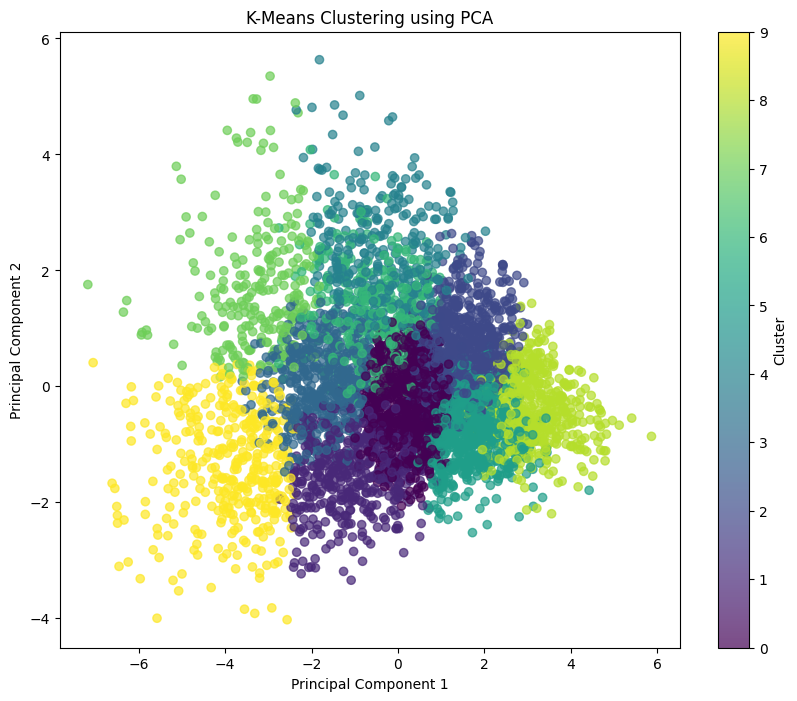

In [26]:
plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters,
    alpha=0.7
)

plt.title(
    "K-Means Clustering using PCA"
)

plt.xlabel(
    "Principal Component 1"
)

plt.ylabel(
    "Principal Component 2"
)

plt.colorbar(
    scatter,
    label="Cluster"
)

plt.show()